# Cronograma interativo da Obra Elétrica — entrada em JSON

Este notebook cria um gráfico de Gantt interativo a partir de um arquivo JSON. Ele preserva a lógica do notebook original: cálculo de fim em dias úteis, marcos, barras de tarefas, ligações de dependência, linha de referência e sombreamento dos fins de semana. A única mudança estrutural é a substituição completa da leitura do arquivo `.gan`/XML pela leitura do JSON.

## Estrutura esperada do JSON

**Entrada:** um objeto JSON com a chave `projeto` e uma lista `tarefas`. **Saída:** uma estrutura validada pronta para os cálculos e o gráfico.

O arquivo fornecido já segue este formato. Campos obrigatórios de cada tarefa: `id`, `nome`, `inicio` (AAAA-MM-DD), `duracao_dias` (inteiro maior que zero), `tipo` (`atividade` ou `marco`) e `depende_de` (lista de IDs). `fim` é opcional para o processamento: quando existir, é conferido com o fim calculado em dias úteis.

```json
{
  "projeto": {"nome": "Nome do projeto", "inicio": "2026-07-27", "fim": "2026-10-07"},
  "tarefas": [
    {
      "id": "T01", "nome": "Uma tarefa", "inicio": "2026-07-27",
      "fim": "2026-07-27", "duracao_dias": 1, "tipo": "marco",
      "depende_de": []
    }
  ]
}
```

Para adaptar outro arquivo, confirme ou ajuste os nomes desses campos nesta seção e nas constantes da célula de validação; não são assumidos campos ocultos. Em `depende_de`, cada ID representa uma tarefa **predecessora**: `T02` com `["T01"]` significa `T01 → T02`.

## 1. Configurar o caminho do arquivo

**Objetivo:** indicar qual JSON será lido. **Entrada:** o caminho do arquivo no computador. **Saída:** `json_path`, um objeto `Path`.

A biblioteca padrão `pathlib` fornece `Path`, uma forma legível e portátil de trabalhar com caminhos. Para trocar a fonte de dados no futuro, altere somente o texto entre aspas abaixo.

In [18]:
from pathlib import Path

json_path = Path("novo_cronograma_obra.json")
# Se o arquivo estiver em outra pasta, informe o caminho completo, por exemplo:
# json_path = Path(r"C:/meus_arquivos/novo_cronograma.json")

print(f"Arquivo de entrada: {json_path.resolve()}")

Arquivo de entrada: C:\Users\pedro\Documents\Obra\TesteComVibeCoding\novo_cronograma_obra.json


## 2. Importar bibliotecas e carregar o JSON

**Objetivo:** abrir o arquivo e convertê-lo para objetos Python. **Entrada:** `json_path`. **Saída:** `dados_json`, normalmente um dicionário.

`json` é uma biblioteca padrão do Python que traduz JSON para dicionários e listas. `datetime.date` representa datas sem horário; `timedelta` permite somar dias. `plotly.graph_objects` cria o gráfico interativo e `plotly.io` o salva como HTML independente. A abordagem usa `encoding="utf-8"` para preservar corretamente acentos.

In [19]:
import json
from datetime import date, timedelta

import plotly.graph_objects as go
import plotly.io as pio

if not json_path.is_file():
    raise FileNotFoundError(
        f"JSON não encontrado: {json_path.resolve()}. Ajuste a célula de configuração do caminho."
    )

try:
    with json_path.open("r", encoding="utf-8") as arquivo_json:
        dados_json = json.load(arquivo_json)
except json.JSONDecodeError as erro:
    raise ValueError(f"O arquivo não contém JSON válido: {erro}") from erro

print("JSON carregado com sucesso.")

JSON carregado com sucesso.


## 3. Validar e normalizar os dados

**Objetivo:** detectar problemas antes de desenhar o gráfico e transformar textos de data em objetos `date`. **Entrada:** `dados_json`. **Saída:** `projeto` e `tarefas` normalizados.

A função abaixo verifica campos obrigatórios, IDs repetidos, formatos de data, duração e referências de dependência. Validar cedo gera mensagens úteis — por exemplo, indicar a tarefa que aponta para um ID inexistente — em vez de um erro difícil de interpretar dentro do Plotly. Valores opcionais são tratados de modo explícito: `fim` pode faltar, e `depende_de` ausente vira uma lista vazia.

In [20]:
CAMPOS_OBRIGATORIOS_TAREFA = {"id", "nome", "inicio", "duracao_dias", "tipo"}
TIPOS_VALIDOS = {"atividade", "marco"}

def converter_data(valor, descricao):
    """Converte uma data ISO (AAAA-MM-DD) em date com erro explicativo."""
    if not isinstance(valor, str):
        raise ValueError(f"{descricao} deve ser texto no formato AAAA-MM-DD.")
    try:
        return date.fromisoformat(valor)
    except ValueError as erro:
        raise ValueError(f"{descricao} inválida: {valor!r}. Use AAAA-MM-DD.") from erro

def validar_e_normalizar(dados):
    if not isinstance(dados, dict):
        raise ValueError("O conteúdo principal do JSON deve ser um objeto.")
    if not isinstance(dados.get("projeto"), dict):
        raise ValueError("Campo obrigatório 'projeto' ausente ou inválido.")
    if not isinstance(dados.get("tarefas"), list) or not dados["tarefas"]:
        raise ValueError("Campo obrigatório 'tarefas' deve ser uma lista não vazia.")

    projeto = dados["projeto"].copy()
    projeto["nome"] = projeto.get("nome", "Cronograma")
    tarefas_normalizadas = []
    ids_encontrados = set()

    for indice, tarefa_bruta in enumerate(dados["tarefas"], start=1):
        if not isinstance(tarefa_bruta, dict):
            raise ValueError(f"Tarefa #{indice} deve ser um objeto JSON.")
        faltantes = CAMPOS_OBRIGATORIOS_TAREFA - tarefa_bruta.keys()
        if faltantes:
            raise ValueError(f"Tarefa #{indice} sem campos obrigatórios: {sorted(faltantes)}.")

        tarefa_id = tarefa_bruta["id"]
        if not isinstance(tarefa_id, str) or not tarefa_id.strip():
            raise ValueError(f"Tarefa #{indice}: 'id' deve ser texto não vazio.")
        if tarefa_id in ids_encontrados:
            raise ValueError(f"ID de tarefa repetido: {tarefa_id!r}.")
        ids_encontrados.add(tarefa_id)

        try:
            duracao = int(tarefa_bruta["duracao_dias"])
        except (TypeError, ValueError) as erro:
            raise ValueError(f"Tarefa {tarefa_id}: 'duracao_dias' deve ser inteiro.") from erro
        if duracao < 1:
            raise ValueError(f"Tarefa {tarefa_id}: 'duracao_dias' deve ser maior ou igual a 1.")
        tipo = tarefa_bruta["tipo"]
        if tipo not in TIPOS_VALIDOS:
            raise ValueError(f"Tarefa {tarefa_id}: 'tipo' deve ser um de {sorted(TIPOS_VALIDOS)}.")
        dependencias = tarefa_bruta.get("depende_de", [])
        if not isinstance(dependencias, list) or not all(isinstance(item, str) for item in dependencias):
            raise ValueError(f"Tarefa {tarefa_id}: 'depende_de' deve ser uma lista de IDs.")

        tarefas_normalizadas.append({
            "id": tarefa_id, "name": tarefa_bruta["nome"],
            "start": converter_data(tarefa_bruta["inicio"], f"Início da tarefa {tarefa_id}"),
            "duration": duracao, "tipo": tipo,
            "depends": dependencias,
            "fim_informado": converter_data(tarefa_bruta["fim"], f"Fim da tarefa {tarefa_id}") if tarefa_bruta.get("fim") else None
        })

    ids_validos = {tarefa["id"] for tarefa in tarefas_normalizadas}
    for tarefa in tarefas_normalizadas:
        desconhecidas = set(tarefa["depends"]) - ids_validos
        if desconhecidas:
            raise ValueError(f"Tarefa {tarefa['id']} depende de IDs inexistentes: {sorted(desconhecidas)}.")
        if tarefa["id"] in tarefa["depends"]:
            raise ValueError(f"Tarefa {tarefa['id']} não pode depender de si mesma.")
    return projeto, tarefas_normalizadas

projeto, tarefas = validar_e_normalizar(dados_json)
by_id = {tarefa["id"]: tarefa for tarefa in tarefas}
print(f"Dados válidos: {len(tarefas)} tarefas no projeto '{projeto['nome']}'.")

Dados válidos: 21 tarefas no projeto 'Obra Elétrica — Bloco N'.


## 4. Calcular fins em dias úteis e conferir o campo `fim`

**Objetivo:** manter o cálculo original de duração em dias úteis (segunda a sexta). **Entrada:** início e duração de cada tarefa. **Saída:** a chave `end` em cada tarefa e uma conferência do `fim` informado.

Um dia útil exclui sábado e domingo. A função começa no próprio dia inicial e avança apenas os dias necessários; assim, duração 1 termina na mesma data, preservando o comportamento do notebook original. O `fim` do JSON é usado como verificação de consistência, e não como substituto silencioso do cálculo.

In [21]:
def adicionar_dias_uteis(inicio, quantidade_dias):
    """Retorna o último dia de uma duração contada em dias úteis."""
    fim = inicio
    for _ in range(quantidade_dias - 1):
        fim += timedelta(days=1)
        while fim.weekday() >= 5:  # 5=sábado e 6=domingo
            fim += timedelta(days=1)
    return fim

for tarefa in tarefas:
    tarefa["end"] = adicionar_dias_uteis(tarefa["start"], tarefa["duration"])
    if tarefa["fim_informado"] and tarefa["fim_informado"] != tarefa["end"]:
        raise ValueError(
            f"Tarefa {tarefa['id']}: fim informado ({tarefa['fim_informado']}) difere do fim "
            f"calculado em dias úteis ({tarefa['end']}). Revise duração, início ou fim."
        )

print("Fins calculados e conferidos com sucesso.")

Fins calculados e conferidos com sucesso.


## 5. Criar barras, marcos e dependências

**Objetivo:** montar os elementos visuais principais do Gantt. **Entrada:** `tarefas` normalizadas e `by_id`. **Saída:** `fig`, uma figura Plotly com barras, diamantes e setas.

`go.Figure()` é o recipiente do gráfico. Uma `Scatter` com linha espessa forma a barra de uma atividade; uma com marcador em losango representa um marco de um dia. As dependências são desenhadas como linhas ortogonais pontilhadas e uma seta. Diferente do `.gan`, o JSON declara predecessoras: a conexão parte do fim da predecessora e chega ao início da tarefa que a lista em `depende_de`.

In [22]:
ys = list(range(len(tarefas) - 1, -1, -1))
task_y = {tarefa["id"]: y for tarefa, y in zip(tarefas, ys)}
fig = go.Figure()

for y, tarefa in zip(ys, tarefas):
    # Se a tarefa tem marco de 1 dia útil plota um diamante
    if tarefa["duration"] == 1:
        fig.add_trace(go.Scatter(
            x=[tarefa["start"]], y=[y], mode="markers",
            marker=dict(symbol="diamond", size=12), text=[tarefa["name"]],
            customdata=[[tarefa["start"].strftime("%d/%m/%Y")]],
            hovertemplate="<b>%{text}</b><br>Data: %{customdata[0]}<br>Marco de 1 dia útil<extra></extra>",
            showlegend=False
        ))
    else:
        dados_hover = [[tarefa["start"].strftime("%d/%m/%Y"), tarefa["end"].strftime("%d/%m/%Y"), tarefa["duration"]]] * 2
        fig.add_trace(go.Scatter(
            x=[tarefa["start"], tarefa["end"]], y=[y, y], mode="lines", line=dict(width=18),
            text=[tarefa["name"]] * 2, customdata=dados_hover,
            hovertemplate="<b>%{text}</b><br>Início: %{customdata[0]}<br>Fim: %{customdata[1]}<br>Duração: %{customdata[2]} dias úteis<extra></extra>",
            showlegend=False
        ))

for tarefa in tarefas:
    y_destino = task_y[tarefa["id"]]
    x_destino = tarefa["start"] - timedelta(days=0.3)
    for id_predecessora in tarefa["depends"]:
        predecessora = by_id[id_predecessora]
        y_origem = task_y[id_predecessora]
        x_origem = predecessora["end"] + timedelta(days=0.5)
        x_chegada = x_destino if x_destino > x_origem else x_origem + timedelta(days=0.7)
        meio = x_origem + (x_chegada - x_origem) / 2
        for x0, y0, x1, y1 in [(x_origem, y_origem, meio, y_origem), (meio, y_origem, meio, y_destino), (meio, y_destino, x_chegada, y_destino)]:
            fig.add_shape(type="line", x0=x0, y0=y0, x1=x1, y1=y1, line=dict(width=1.5, dash="dot"))
        fig.add_annotation(x=x_chegada, y=y_destino, ax=x_chegada - timedelta(days=0.8), ay=y_destino, xref="x", yref="y", axref="x", ayref="y", showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1.5, text="")

## 6. Configurar a escala temporal e o layout

**Objetivo:** acrescentar a linha de hoje, destacar fins de semana e definir aparência, controles e rótulos. **Entrada:** `fig` e as datas calculadas. **Saída:** gráfico final configurado.

`date.today()` evita uma data fixa: a linha se atualiza automaticamente a cada execução. `add_vrect` cria faixas de fundo para sábados e domingos, e `update_layout` concentra configurações de título, eixos, altura e botões de navegação.

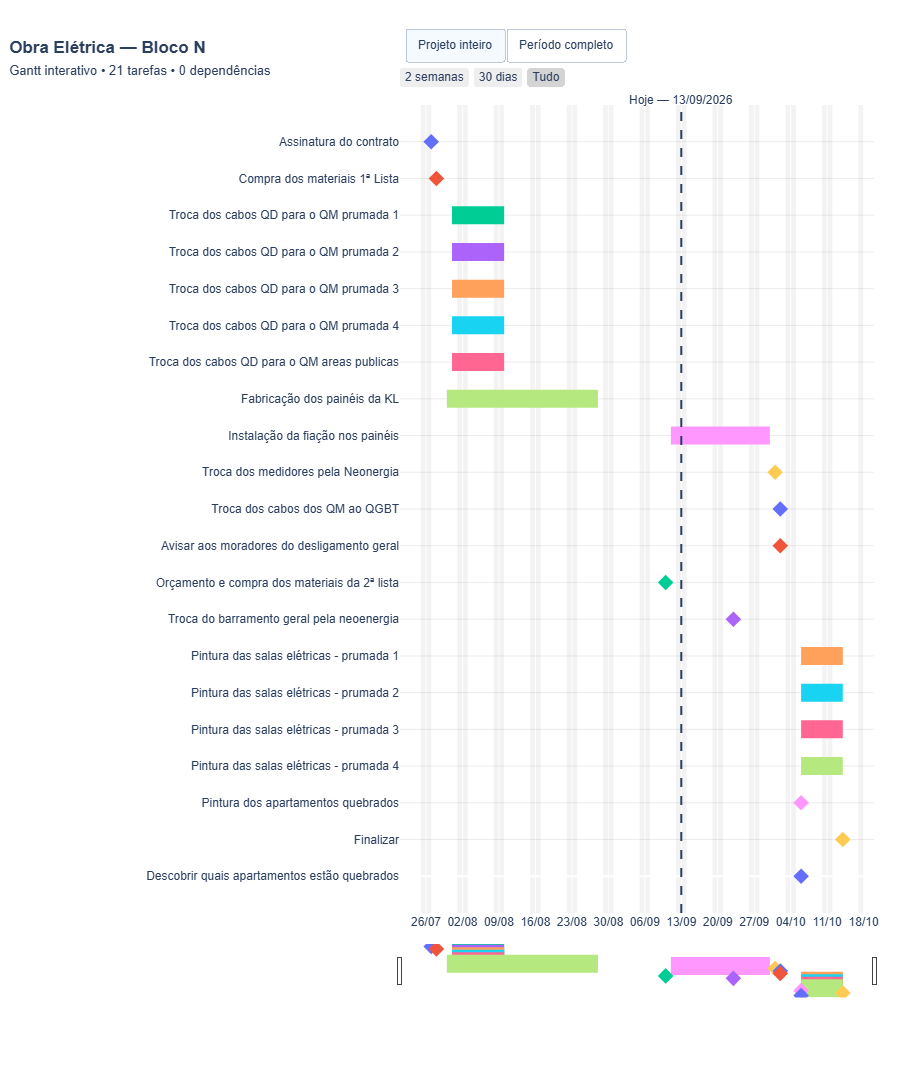

In [23]:
hoje = date.today()
min_date = min(tarefa["start"] for tarefa in tarefas) - timedelta(days=2)
max_date = max(tarefa["end"] for tarefa in tarefas) + timedelta(days=3)

fig.add_shape(type="line", x0=str(hoje), x1=str(hoje), y0=-1, y1=len(tarefas), line=dict(width=2, dash="dash"))
fig.add_annotation(x=str(hoje), y=len(tarefas) - 0.2, text=f"Hoje — {hoje.strftime('%d/%m/%Y')}", showarrow=False, yshift=12)

dia = min_date
while dia <= max_date:
    if dia.weekday() >= 5:
        fig.add_vrect(x0=str(dia), x1=str(dia + timedelta(days=1)), fillcolor="rgba(100,100,100,0.08)", line_width=0, layer="below")
    dia += timedelta(days=1)

quantidade_dependencias = sum(len(tarefa["depends"]) for tarefa in tarefas)
fig.update_layout(
    title=dict(text=f"<b>{projeto['nome']}</b><br><span style='font-size:13px'>Gantt interativo • {len(tarefas)} tarefas • {quantidade_dependencias} dependências</span>", x=0.01, xanchor="left"),
    height=max(600, 80 + len(tarefas) * 48), margin=dict(l=400, r=45, t=105, b=90),
    hovermode="closest", dragmode="pan", plot_bgcolor="white", paper_bgcolor="white", font=dict(family="Arial", size=12), showlegend=False,
    xaxis=dict(type="date", tickformat="%d/%m", dtick=7 * 24 * 60 * 60 * 1000, showgrid=True, rangeslider=dict(visible=True, thickness=0.06), rangeselector=dict(buttons=[dict(count=14, label="2 semanas", step="day", stepmode="backward"), dict(count=30, label="30 dias", step="day", stepmode="backward"), dict(step="all", label="Tudo")])),
    yaxis=dict(tickmode="array", tickvals=ys, ticktext=[tarefa["name"] for tarefa in tarefas], autorange=False, range=[-1, len(tarefas)], showgrid=True, gridcolor="rgba(0,0,0,0.08)"),
    updatemenus=[dict(type="buttons", direction="right", x=0.01, y=1.055, xanchor="left", yanchor="bottom", buttons=[dict(label="Projeto inteiro", method="relayout", args=[{"xaxis.autorange": True}]), dict(label="Período completo", method="relayout", args=[{"xaxis.range": [str(min_date), str(max_date)]}])])]
)

## 7. Exibir e exportar o resultado

**Objetivo:** visualizar o Gantt no notebook e criar um HTML compartilhável. **Entrada:** `fig` configurada. **Saída:** gráfico exibido e arquivo `Gantt_Obra_Eletrica_interativo.html` na mesma pasta do JSON.

`fig.show()` abre a visualização interativa no Jupyter. `pio.write_html` grava uma página que inclui o JavaScript do Plotly, portanto pode ser aberta offline em um navegador.

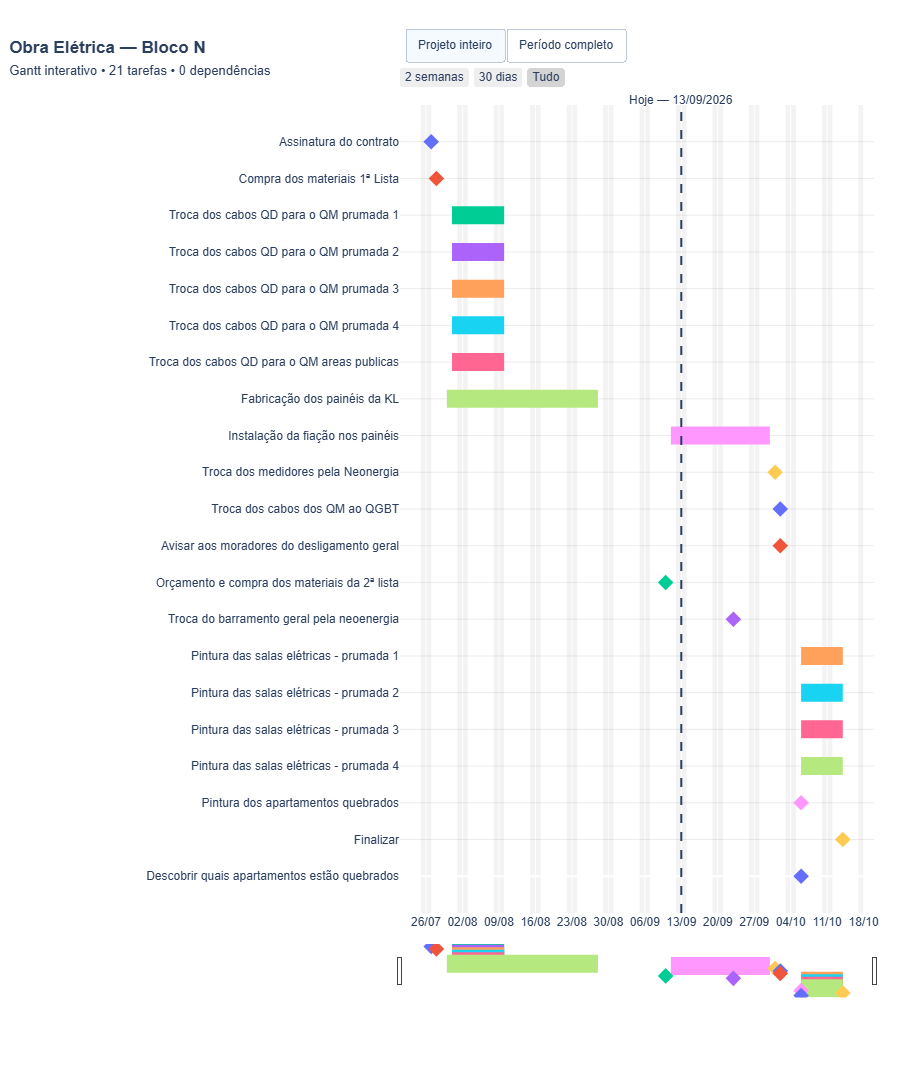

HTML criado com sucesso: C:\Users\pedro\Documents\Obra\TesteComVibeCoding\Gantt_Obra_Eletrica_interativo.html
21 tarefas e 0 dependências importadas do JSON.


In [24]:
html_path = json_path.parent / "Gantt_Obra_Eletrica_interativo.html"

fig.show()

pio.write_html(fig, file=str(html_path), include_plotlyjs=True, full_html=True, auto_open=False, config={
    "responsive": True, "displaylogo": False, "scrollZoom": True,
    "displayModeBar": True, "doubleClick": "reset"
})

print(f"HTML criado com sucesso: {html_path.resolve()}")
print(f"{len(tarefas)} tarefas e {quantidade_dependencias} dependências importadas do JSON.")

## Resumo do fluxo

1. A célula inicial define o caminho do JSON.
2. O arquivo é carregado com `json.load` e sua existência/formatação é verificada.
3. As tarefas são validadas, normalizadas e as datas passam de texto para objetos `date`.
4. O fim de cada tarefa é calculado em dias úteis e comparado ao `fim` informado, quando presente.
5. O Plotly gera barras para atividades, diamantes para marcos e setas das predecessoras para suas sucessoras.
6. O layout acrescenta linha de hoje, fins de semana, controles de escala e rótulos.
7. O resultado é exibido no notebook e salvo como HTML interativo offline.